# Attentional Spatial Bias — Analysis

Ported from `attentional_spatial_bias_colab.py` (written by someone else, not
verified before this notebook). Before porting, the script's logic was
checked against the real trial-log data in `data/raw/`, and two real bugs
were found and fixed here — see the notes before each section.

**Data used:** `subject-43` (LTR, German), `subject-44` (RTL, Arabic), and
`subject-51` (LTR, English) — the files in `data/raw/` with the full
48-trial, 6-arrangement design and a `block_index` column. The other files
in that folder (`subject-1/3/50/83`) are earlier pilot/demo runs with a
different, incompatible design (only 4 position codes, whose pixel offsets
don't match the `POSITION_LABELS` scheme below, no `block_index`, and in two
of the four files `first_fix_side` uses a different text encoding). They are
excluded here rather than force-fit into this pipeline.

**Caveat kept from the original script:** the RTL group still has a single
subject (44), so `group` and `subject_nr` remain perfectly confounded for
that group — any LTR-vs-RTL contrast is equally well described as "subject
44 vs the rest". The LTR group now has two subjects (43, 51), so
within-LTR spread is at least informative, but LTR-vs-RTL comparisons should
still be treated as descriptive/pilot output only, not as evidence for or
against a reading-direction effect.

## 1. Setup

In [1]:
import glob
import os
import math

import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

try:
    from statsmodels.tools.sm_exceptions import PerfectSeparationError
except ImportError:  # newer statsmodels may drop/rename it
    class PerfectSeparationError(Exception):
        pass

## 2. Data location

Analysis is restricted to the two full-design subject files.

In [2]:
DATA_DIR = "../data/raw"
SUBJECTS = ["subject-43", "subject-44", "subject-51"]
OUT_DIR = "results"
os.makedirs(OUT_DIR, exist_ok=True)

for s in SUBJECTS:
    for ext in (".csv", ".tsv"):
        p = os.path.join(DATA_DIR, s + ext)
        assert os.path.exists(p), f"missing {p}"
print("Data files found for:", SUBJECTS)

Data files found for: ['subject-43', 'subject-44', 'subject-51']


## 3. Config: arrangement / clock mapping

**Bug found and fixed here:** the original script hardcoded a
`POSITION_LABELS` (position code → arrangement name, e.g. `"nine-three"`)
plus a separate `CLOCK_MAP` (arrangement + side → clock hour). Its own
`inspect_positions()` helper derives the clock hour from pixel offsets using
`atan2(y, x)` under a **math convention (y-up)**, but the logged
`x_left/y_left/x_right/y_right` offsets are in **screen convention (y-down)**
— confirmed by `scripts/data_evaluation.ipynb`, which places stimuli on
screen via `540 + y_left` with no sign flip, and by rendering scanpaths that
line up correctly with that convention.

Feeding y-down data into a y-up formula silently mirrors every arrangement
top-to-bottom except the purely horizontal one. Checked against subject-43/44's
actual pixel offsets, position `4` (a vertical pair) is really `(12, 6)`
(left image at the top of the screen = 12 o'clock, right at the bottom = 6
o'clock) but the original code assigned `(6, 12)` — swapped. Positions 2/3/5/6
are likewise mislabeled (each a mirror-image swap with another position).

Fixed by using the *pixel offsets themselves* as clock-hour pairs rather than
maintaining two hand-written lookup tables that can drift out of sync — the
label *is* the clock position, so there's nothing left to fix in a `CLOCK_MAP`
the next time position codes change.

**Design issue found (not a coding bug, a labeling issue):** the six
arrangements are the six possible diameters of a 12-hour clock face (there
are only six, since e.g. the 1–7 line and the 7–1 line are the same line).
Plotting real `x_left`/`x_right` for all six confirms `img_left` is always
the stimulus at clock-hour 7–12 and `img_right` is always the one at 1–6 —
a consistent split, but **not the same thing as "screen left/right"**:
hours 12 and 6 sit exactly on the vertical meridian (`x = 0`), so for that
one arrangement there is no physical left/right at all — both images are
directly above/below center. Calling `img_right` for that arrangement "the
RIGHT stimulus" is misleading; it's really "the BOTTOM stimulus". The
original script's `mean_p_right` plot inherits this issue.

Fixed by keeping the actual fixated **clock hour** as the primary recorded
value (Section 4) instead of a binary left/right label, and deriving
left/right and up/down summaries from it afterwards (Section 9) — each
excluding the arrangement(s) for which that axis has no physical meaning
(`12`/`6` for left-right, `3`/`9` for up-down).

In [3]:
POSITION_LABELS = {
    "1": (9, 3), "2": (10, 4), "3": (11, 5),
    "4": (12, 6), "5": (7, 1), "6": (8, 2),
}
ARRANGEMENT_ORDER = [(7, 1), (8, 2), (9, 3), (10, 4), (11, 5), (12, 6)]
CLOCK_ORDER = list(range(1, 13))

RT_EXCLUSION_MS = 2000
MIN_LATENCY_MS = 80   # saccades planned before stimulus onset land faster than this
WINSOR_PROP = 0.2
N_BOOT = 5000
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)


def clock_hour_from_xy(x, y):
    # clock hour for a point at screen offset (x, y) from center, y-down
    angle = math.degrees(math.atan2(y, x))
    h = (round(angle / 30.0) + 3) % 12
    return 12 if h == 0 else h


def clock_for_side(arrangement, side):
    return arrangement[0] if side == "left" else arrangement[1]


def hour_side(hour):
    # physical screen left/right of a clock hour; 6 and 12 sit on the
    # vertical meridian (x=0) and have no left/right meaning
    if pd.isna(hour):
        return np.nan
    if hour in (6, 12):
        return np.nan
    return "left" if hour in (7, 8, 9, 10, 11) else "right"


def hour_vert(hour):
    # physical screen up/down of a clock hour; 3 and 9 sit on the
    # horizontal meridian (y=0) and have no up/down meaning
    if pd.isna(hour):
        return np.nan
    if hour in (3, 9):
        return np.nan
    return "up" if hour in (10, 11, 12, 1, 2) else "down"

In [4]:
# Sanity-check POSITION_LABELS against the actual logged pixel offsets
seen = {}
for s in SUBJECTS:
    df = pd.read_csv(os.path.join(DATA_DIR, s + ".csv"), dtype=str)
    for _, row in df.iterrows():
        pos = row["position"]
        if pos not in seen:
            seen[pos] = (float(row["x_left"]), float(row["y_left"]),
                         float(row["x_right"]), float(row["y_right"]))

print(f"{'position':>8} {'computed':>10} {'expected':>10}  status")
for pos in sorted(seen, key=int):
    xl, yl, xr, yr = seen[pos]
    computed = (clock_hour_from_xy(xl, yl), clock_hour_from_xy(xr, yr))
    expected = POSITION_LABELS[pos]
    status = "OK" if computed == expected else "MISMATCH"
    print(f"{pos:>8} {str(computed):>10} {str(expected):>10}  {status}")

position   computed   expected  status
       1     (9, 3)     (9, 3)  OK
       2    (10, 4)    (10, 4)  OK
       3    (11, 5)    (11, 5)  OK
       4    (12, 6)    (12, 6)  OK
       5     (7, 1)     (7, 1)  OK
       6     (8, 2)     (8, 2)  OK


## 4. Load + tidy the subject CSVs

`block_index` is required here (both subject-43/44 have it); the pilot files
that lack it are excluded by the `SUBJECTS` list above rather than by a
try/except, since their `position` codes mean something different anyway.

`fix_direction()` handles both text encodings for `first_fix_side` seen in
this dataset (image filename, or a literal `"LEFT"`/`"RIGHT"`/`"none"`) even
though subject-43/44 only use the filename form — cheap to support since a
pilot file in this same folder already used the other form.

In [5]:
def load_subject_csv(path):
    df = pd.read_csv(path, dtype=str)
    keep_cols = [
        "subject_nr", "group", "lang", "trial_nr", "block_index",
        "position", "img_left", "img_right",
        "x_left", "y_left", "x_right", "y_right",
        "first_fix_side", "first_fix_rt", "response_time", "correct",
    ]
    missing = [c for c in keep_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{path}: missing expected columns {missing}")
    df = df[keep_cols].copy()

    df["trial_nr"] = df["trial_nr"].astype(int)
    df["block_index"] = df["block_index"].astype(int)
    for c in ["first_fix_rt", "response_time", "x_left", "y_left", "x_right", "y_right"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df["arrangement"] = df["position"].map(POSITION_LABELS)
    if df["arrangement"].isna().any():
        bad = df.loc[df["arrangement"].isna(), "position"].unique()
        raise ValueError(f"{path}: unmapped position code(s) {bad} -- update POSITION_LABELS")

    def fix_direction(row):
        side = row["first_fix_side"]
        if pd.isna(side) or side == "none":
            return "none"
        if side == row["img_left"]:
            return "left"
        if side == row["img_right"]:
            return "right"
        su = str(side).strip().upper()
        if su in ("LEFT", "RIGHT"):
            return su.lower()
        return "none"

    df["first_fix_direction"] = df.apply(fix_direction, axis=1)
    df["fixated_clock"] = df.apply(
        lambda r: clock_for_side(r["arrangement"], r["first_fix_direction"])
        if r["first_fix_direction"] != "none" else np.nan, axis=1)
    df["physical_side"] = df["fixated_clock"].map(hour_side)
    df["physical_vert"] = df["fixated_clock"].map(hour_vert)

    reading_start_side = {"LTR": "left", "RTL": "right"}
    df["reading_start_side"] = df["group"].map(reading_start_side)
    df["fix_matches_reading_onset"] = (
        df["first_fix_direction"] == df["reading_start_side"]
    ).where(df["first_fix_direction"] != "none")

    df.rename(columns={"first_fix_rt": "first_fix_rt_ms",
                        "response_time": "response_time_ms"}, inplace=True)
    df["subject_nr"] = df["subject_nr"].astype(str)
    return df


def apply_exclusions(df, side_col="first_fix_direction", rt_col="first_fix_rt_ms",
                      rt_cutoff_ms=RT_EXCLUSION_MS, min_latency_ms=None,
                      reason_col="exclusion_reason", excluded_col="excluded"):
    # min_latency_ms=None keeps the original script's behaviour (no lower
    # bound); the FPOG-based pass sets it to MIN_LATENCY_MS to drop
    # anticipatory first fixations.
    df = df.copy()
    df[reason_col] = "none"
    no_fix = df[side_col] == "none"
    df.loc[no_fix, reason_col] = "no_first_fixation_registered"
    too_slow = (~no_fix) & (df[rt_col] > rt_cutoff_ms)
    df.loc[too_slow, reason_col] = "first_fix_rt_over_cutoff"
    if min_latency_ms is not None:
        too_fast = (~no_fix) & (df[rt_col] < min_latency_ms)
        df.loc[too_fast, reason_col] = "first_fix_anticipatory"
    df[excluded_col] = df[reason_col] != "none"
    return df


paths = [os.path.join(DATA_DIR, s + ".csv") for s in SUBJECTS]
frames = [load_subject_csv(p) for p in paths]
trials = pd.concat(frames, ignore_index=True)
trials = apply_exclusions(trials)
trials.to_csv(os.path.join(OUT_DIR, "trials_combined.csv"), index=False)

n_subj = trials["subject_nr"].nunique()
n_excl = trials["excluded"].sum()
print(f"Loaded {len(paths)} file(s), {n_subj} subject(s), {len(trials)} trials.")
print(f"Excluded {n_excl}/{len(trials)} trials ({n_excl/len(trials):.1%}) "
      f"(no fixation registered, or RT > {RT_EXCLUSION_MS} ms).")

df_valid = trials[~trials["excluded"]].copy()

Loaded 3 file(s), 3 subject(s), 144 trials.
Excluded 37/144 trials (25.7%) (no fixation registered, or RT > 2000 ms).


## 5. Bootstrap helpers

`bootstrap_ci` / `winsorized_mean` are unchanged from the original script.
`hierarchical_bootstrap_ci` is new: for group-pooled estimates it resamples
**subjects first, then trials within each resampled subject**, so trials from
the same subject are not treated as independent (they aren't). Its point
estimate is the unweighted mean of subject means. With a single subject it
degenerates to a plain trial bootstrap of that subject; with the planned
10+ subjects it needs no code change. `bt_fit_is_suspect` flags a logistic
fit that silently diverged (perfect separation can return inf/huge
coefficients with only a warning instead of raising).

In [6]:
def bootstrap_ci(values, stat_fn, n_boot=N_BOOT):
    values = np.asarray(values)
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    point = stat_fn(values)
    if len(values) < 2:
        return point, np.nan, np.nan
    boots = np.empty(n_boot)
    n = len(values)
    for i in range(n_boot):
        boots[i] = stat_fn(values[rng.integers(0, n, n)])
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return point, lo, hi


def winsorized_mean(x, prop=WINSOR_PROP):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    if n == 0:
        return np.nan
    k = int(np.floor(prop * n))
    if k > 0:
        x = np.concatenate([np.full(k, x[k]), x[k:n - k], np.full(k, x[n - 1 - k])])
    return x.mean()


def hierarchical_bootstrap_ci(arrays, n_boot=N_BOOT):
    # arrays: one 0/1 (or numeric) array per subject.
    # Stage 1 resamples subjects, stage 2 resamples trials within each
    # sampled subject. Point estimate = unweighted mean of subject means.
    arrays = [np.asarray(a, dtype=float) for a in arrays if len(a) > 0]
    k = len(arrays)
    if k == 0:
        return np.nan, np.nan, np.nan
    point = float(np.mean([a.mean() for a in arrays]))
    boots = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, k, k) if k > 1 else np.zeros(1, dtype=int)
        boots[i] = np.mean([arrays[j][rng.integers(0, len(arrays[j]), len(arrays[j]))].mean()
                            for j in idx])
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return point, lo, hi


def bt_fit_is_suspect(model):
    # statsmodels can "succeed" through perfect separation, returning
    # non-converged or inf/huge coefficients with only a warning
    conv = getattr(model, "mle_retvals", {}).get("converged", True)
    params = np.asarray(model.params, dtype=float)
    bse = np.asarray(model.bse, dtype=float)
    return (not conv) or (~np.isfinite(params)).any() or (np.abs(params) > 15).any() \
        or (~np.isfinite(bse)).any()


colors = {"LTR": "#1f77b4", "RTL": "#d62728"}

## 6. Original analysis, using the CSV's `first_fix_side` column

This block keeps the original script's approach: trust the `first_fix_side`
column that OpenSesame logged. **Important caveat, found while checking this
script against the raw gaze data (see Section 9 below): this column never
once reports a rightward first fixation for either subject (0/96 trials),
while the raw eye-tracker fixation stream shows ~25 genuine rightward first
fixations.** The OpenSesame-side fixation-detection logic that produced this
column appears to be broken. Numbers below are kept for reference /
comparison, not as the primary result — see Section 10 for the corrected
version.


=== Mean choice proportion by arrangement (CSV first_fix_side) ===
subject_nr group arrangement  n_trials  mean_p_right  ci_lo  ci_hi
        43   LTR      (7, 1)         3         0.000  0.000  0.000
        44   RTL      (7, 1)         2         0.000  0.000  0.000
        51   LTR      (7, 1)         8         0.875  0.625  1.000
        43   LTR      (8, 2)         2         0.000  0.000  0.000
        44   RTL      (8, 2)         3         0.000  0.000  0.000
        51   LTR      (8, 2)         8         0.500  0.125  0.875
        43   LTR      (9, 3)         8         0.000  0.000  0.000
        44   RTL      (9, 3)         8         0.000  0.000  0.000
        51   LTR      (9, 3)         8         0.125  0.000  0.375
        43   LTR     (10, 4)         8         0.000  0.000  0.000
        44   RTL     (10, 4)         8         0.000  0.000  0.000
        51   LTR     (10, 4)         8         0.500  0.125  0.875
        43   LTR     (11, 5)         8         0.000  0.000  

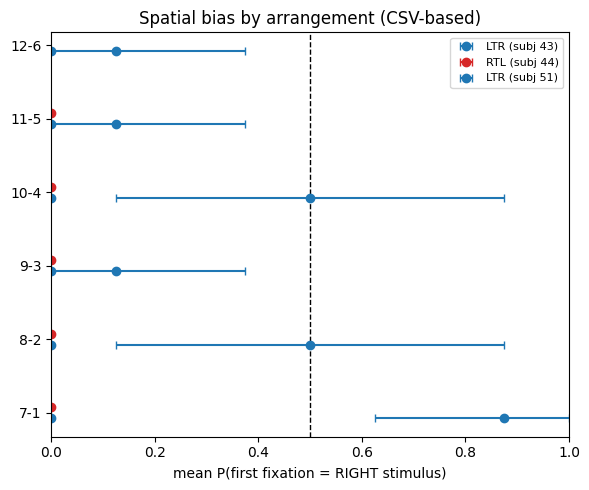

In [7]:
rows = []
for (subj, group, arr), g in df_valid.groupby(["subject_nr", "group", "arrangement"]):
    is_right = (g["first_fix_direction"] == "right").astype(float).values
    point, lo, hi = bootstrap_ci(is_right, np.mean)
    rows.append(dict(subject_nr=subj, group=group, arrangement=arr,
                      n_trials=len(g), mean_p_right=point, ci_lo=lo, ci_hi=hi))
choice_df_csv = pd.DataFrame(rows)
choice_df_csv["arrangement"] = pd.Categorical(choice_df_csv["arrangement"], ARRANGEMENT_ORDER, ordered=True)
choice_df_csv = choice_df_csv.sort_values(["arrangement", "subject_nr"]).reset_index(drop=True)
choice_df_csv.to_csv(os.path.join(OUT_DIR, "choice_proportion_by_arrangement_csv.csv"), index=False)

print("\n=== Mean choice proportion by arrangement (CSV first_fix_side) ===")
print(choice_df_csv.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 5))
y_pos = {a: i for i, a in enumerate(ARRANGEMENT_ORDER)}
groups_sorted = sorted(choice_df_csv["group"].unique())
offsets = {g: (i - (len(groups_sorted) - 1) / 2) * 0.15 for i, g in enumerate(groups_sorted)}
for _, row in choice_df_csv.iterrows():
    y = y_pos[row["arrangement"]] + offsets[row["group"]]
    ax.errorbar(row["mean_p_right"], y,
                xerr=[[row["mean_p_right"] - row["ci_lo"]], [row["ci_hi"] - row["mean_p_right"]]],
                fmt="o", color=colors.get(row["group"], "gray"),
                label=f"{row['group']} (subj {row['subject_nr']})", capsize=3)
ax.axvline(0.5, linestyle="--", color="black", linewidth=1)
ax.set_yticks(range(len(ARRANGEMENT_ORDER)))
ax.set_yticklabels([f"{a[0]}-{a[1]}" for a in ARRANGEMENT_ORDER])
ax.set_xlabel("mean P(first fixation = RIGHT stimulus)")
ax.set_xlim(0, 1)
ax.set_title("Spatial bias by arrangement (CSV-based)")
handles, labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys(), fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig2_left_choice_proportion_csv.png"), dpi=150)
plt.show()


=== 20%-winsorized mean RT by clock location (CSV-based) ===
subject_nr group clock  n_trials  winsor_mean_rt_s    ci_lo    ci_hi
        51   LTR     1         7          0.249871 0.208941 0.354456
        51   LTR     2         4          0.242076 0.213830 0.283595
        51   LTR     3         1          0.205641      NaN      NaN
        51   LTR     4         4          0.245027 0.211707 0.288945
        51   LTR     5         1          0.349540      NaN      NaN
        51   LTR     6         1          0.221908      NaN      NaN
        43   LTR     7         3          0.032192 0.031570 0.032684
        44   RTL     7         2          1.063711 0.950651 1.176771
        51   LTR     7         1          0.264130      NaN      NaN
        43   LTR     8         2          0.400536 0.030755 0.770317
        44   RTL     8         3          0.162219 0.031171 0.252351
        51   LTR     8         4          0.191481 0.186170 0.198064
        43   LTR     9         8         

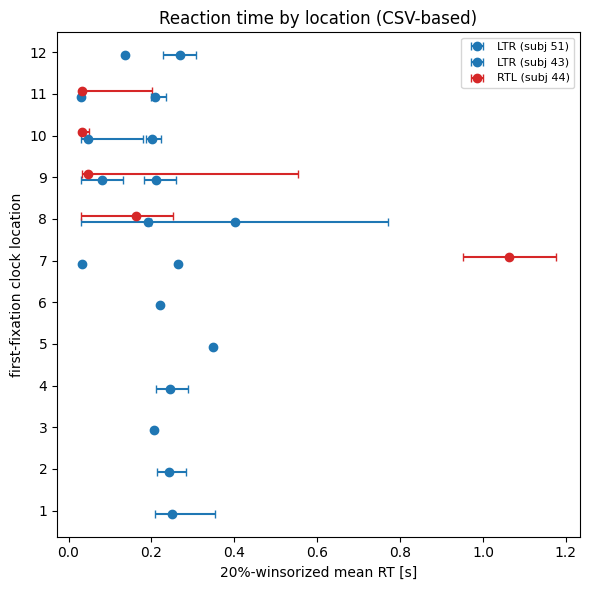

In [8]:
df_rt = df_valid.copy()
df_rt["clock"] = df_rt.apply(lambda r: clock_for_side(r["arrangement"], r["first_fix_direction"]), axis=1)

rows = []
for (subj, group, clock), g in df_rt.groupby(["subject_nr", "group", "clock"]):
    rt = g["first_fix_rt_ms"].values / 1000.0
    point, lo, hi = bootstrap_ci(rt, winsorized_mean)
    rows.append(dict(subject_nr=subj, group=group, clock=clock,
                      n_trials=len(g), winsor_mean_rt_s=point, ci_lo=lo, ci_hi=hi))
rt_df_csv = pd.DataFrame(rows)
rt_df_csv["clock"] = pd.Categorical(rt_df_csv["clock"], CLOCK_ORDER, ordered=True)
rt_df_csv = rt_df_csv.sort_values(["clock", "subject_nr"]).reset_index(drop=True)
rt_df_csv.to_csv(os.path.join(OUT_DIR, "reaction_time_by_location_csv.csv"), index=False)

print("\n=== 20%-winsorized mean RT by clock location (CSV-based) ===")
print(rt_df_csv.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 6))
y_pos = {c: i for i, c in enumerate(CLOCK_ORDER)}
for _, row in rt_df_csv.iterrows():
    y = y_pos[row["clock"]] + offsets.get(row["group"], 0)
    lo = row["winsor_mean_rt_s"] - row["ci_lo"] if not np.isnan(row["ci_lo"]) else 0
    hi = row["ci_hi"] - row["winsor_mean_rt_s"] if not np.isnan(row["ci_hi"]) else 0
    ax.errorbar(row["winsor_mean_rt_s"], y, xerr=[[lo], [hi]], fmt="o",
                color=colors.get(row["group"], "gray"),
                label=f"{row['group']} (subj {row['subject_nr']})", capsize=3)
ax.set_yticks(range(len(CLOCK_ORDER)))
ax.set_yticklabels([str(c) for c in CLOCK_ORDER])
ax.set_ylabel("first-fixation clock location")
ax.set_xlabel("20%-winsorized mean RT [s]")
ax.set_title("Reaction time by location (CSV-based)")
handles, labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys(), fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig2_right_reaction_times_csv.png"), dpi=150)
plt.show()

Bradley-Terry-style logistic regression of first-fixation side (CSV-based).

In [9]:
d = df_valid.copy()
d["y_right"] = (d["first_fix_direction"] == "right").astype(int)
d["arrangement_str"] = d["arrangement"].astype(str)
mod = smf.logit("y_right ~ C(arrangement_str) + C(group)", data=d)
# Perfect separation may raise PerfectSeparationError, raise LinAlgError, or
# "succeed" with inf/diverged coefficients and only a warning -- catch all three.
note = ""
try:
    model = mod.fit(disp=False)
    if bt_fit_is_suspect(model):
        raise PerfectSeparationError("fit diverged (non-finite or huge coefficients)")
except (np.linalg.LinAlgError, PerfectSeparationError):
    model = mod.fit_regularized(alpha=0.5, disp=False)
    note = ("[NOTE: unregularized fit hit perfect separation / divergence -- "
            "some arrangement x group cells are all-left or all-right with "
            "this small n. Refit with an L1 penalty below; treat coefficients "
            "as descriptive only, not as p<.05-testable effects, until you "
            "add more subjects.]\n")

print("\n=== Bradley-Terry-style logistic regression: P(right) ~ arrangement + group (CSV-based) ===")
if note:
    print(note)
print(model.summary() if hasattr(model, "summary") else model.params)
print("\nCAUTION: RTL still has only 1 subject, so `group` is confounded with "
      "`subject_nr` for that group -- treat as descriptive/pilot output only.")

with open(os.path.join(OUT_DIR, "bradley_terry_model_summary_csv.txt"), "w") as f:
    f.write(note)
    f.write(str(model.summary() if hasattr(model, "summary") else model.params))


=== Bradley-Terry-style logistic regression: P(right) ~ arrangement + group (CSV-based) ===
[NOTE: unregularized fit hit perfect separation / divergence -- some arrangement x group cells are all-left or all-right with this small n. Refit with an L1 penalty below; treat coefficients as descriptive only, not as p<.05-testable effects, until you add more subjects.]

                           Logit Regression Results                           
Dep. Variable:                y_right   No. Observations:                  107
Model:                          Logit   Df Residuals:                      100
Method:                           MLE   Df Model:                            6
Date:                Wed, 15 Jul 2026   Pseudo R-squ.:                  0.2881
Time:                        02:18:00   Log-Likelihood:                -34.512
converged:                       True   LL-Null:                       -48.477
Covariance Type:            nonrobust   LLR p-value:                 9.682e-05
 

/Users/jun/Documents/hw/ET/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Extra: LTR vs RTL reading-onset congruence (CSV-based).


=== P(first fixation matches reading-onset side), by group (CSV-based) ===
(reading-onset side = left for LTR readers, right for RTL readers)
subject_nr group  n_trials  p_reading_congruent  ci_lo  ci_hi
        43   LTR        30                1.000    1.0   1.00
        44   RTL        29                0.000    0.0   0.00
        51   LTR        48                0.625    0.5   0.75

2x2 table (group x matches-reading-onset):
fix_matches_reading_onset  False  True 
group                                  
LTR                           18     60
RTL                           29      0

Fisher's exact test: odds ratio = 0.000, p = 0.0000

CAUTION: with 1 subject per group this compares two individuals, not two populations.


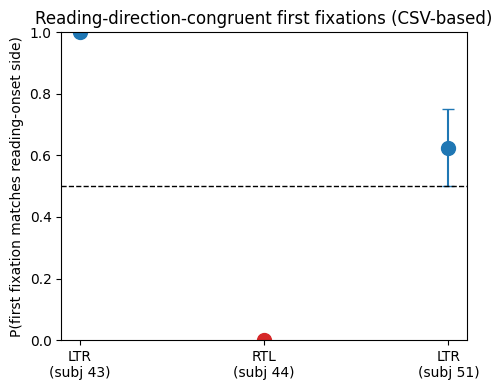

In [10]:
rows = []
for (subj, group), g in df_valid.groupby(["subject_nr", "group"]):
    match = g["fix_matches_reading_onset"].dropna().astype(float).values
    point, lo, hi = bootstrap_ci(match, np.mean)
    rows.append(dict(subject_nr=subj, group=group, n_trials=len(match),
                      p_reading_congruent=point, ci_lo=lo, ci_hi=hi))
congruence_df_csv = pd.DataFrame(rows)
congruence_df_csv.to_csv(os.path.join(OUT_DIR, "reading_congruence_by_group_csv.csv"), index=False)

table = (df_valid.dropna(subset=["fix_matches_reading_onset"])
         .groupby(["group", "fix_matches_reading_onset"]).size().unstack(fill_value=0))
odds_ratio, fisher_p = (np.nan, np.nan)
if table.shape == (2, 2):
    odds_ratio, fisher_p = stats.fisher_exact(table.values)

print("\n=== P(first fixation matches reading-onset side), by group (CSV-based) ===")
print("(reading-onset side = left for LTR readers, right for RTL readers)")
print(congruence_df_csv.to_string(index=False))
print("\n2x2 table (group x matches-reading-onset):")
print(table)
if not np.isnan(fisher_p):
    print(f"\nFisher's exact test: odds ratio = {odds_ratio:.3f}, p = {fisher_p:.4f}")
print("\nCAUTION: with 1 subject per group this compares two individuals, not two populations.")

fig, ax = plt.subplots(figsize=(5, 4))
for i, row in enumerate(congruence_df_csv.itertuples()):
    lo = row.p_reading_congruent - row.ci_lo if not np.isnan(row.ci_lo) else 0
    hi = row.ci_hi - row.p_reading_congruent if not np.isnan(row.ci_hi) else 0
    ax.errorbar(i, row.p_reading_congruent, yerr=[[lo], [hi]], fmt="o",
                markersize=10, color=colors.get(row.group, "gray"), capsize=4)
ax.axhline(0.5, linestyle="--", color="black", linewidth=1)
ax.set_xticks(range(len(congruence_df_csv)))
ax.set_xticklabels([f"{r.group}\n(subj {r.subject_nr})" for r in congruence_df_csv.itertuples()])
ax.set_ylabel("P(first fixation matches reading-onset side)")
ax.set_ylim(0, 1)
ax.set_title("Reading-direction-congruent first fixations (CSV-based)")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "extra_reading_congruence_csv.png"), dpi=150)
plt.show()

## 7. Verifying `first_fix_side` against the raw eye-tracker samples

`first_fix_side` in the CSV is not a raw measurement — it's a value the
OpenSesame experiment script computed from the live gaze stream and logged.
Since this script (and that one) were both written by someone else, this
step cross-checks it independently, using the columns the eye tracker itself
produces:

- `FPOGX`/`FPOGY` (**F**ixation **PO**int of **G**aze) are GazePoint's own
  fixation-classified gaze coordinates, not raw per-sample gaze — the
  tracker groups consecutive samples into fixations via `FPOGID`, with
  `FPOGS`/`FPOGD` giving each fixation's start time/duration.
- The `.tsv` also carries `USER` markers (`STIMULUS_ONSET`, `IMAGE_OFFSET`)
  tagged with `TRIAL=`, `IMG_LEFT=`, `IMG_RIGHT=` — the same markers
  `scripts/data_evaluation.ipynb` uses to segment trials for its scanpath
  plots.

For each trial: take the `FPOGID`-grouped fixations that fall inside
`STIMULUS_ONSET`→`IMAGE_OFFSET`, in time order, and find the first one that
lands inside either stimulus **AOI**.

**AOI definition (from the experiment script `src/V7_AttentionalSpatialBias_.osexp`):**
the stimuli are 1025×1025 px images drawn at `scale=0.25` → **~256×256 px on
screen**, centered at `960 + x_left/x_right`, `540 + y_left/y_right` (the
convention validated in Section 3). The experiment's own online detection
used a square AOI of half-width `margin = 150` px around each stimulus
center; the same square AOI is used here (half-size 128 px + ~22 px slack
for calibration error). Stimulus centers are 616 px apart, so the AOIs can
never overlap. A fixation outside both AOIs is skipped — this replaces the
earlier "closer to one stimulus by >100 px" rule, which could classify a
fixation far away from *both* stimuli.

**Anticipatory-fixation handling:** a central fixation dot precedes the
stimuli, so the fixation in progress at stimulus onset is just the
continuation of that dot fixation — only fixations that *start* at or after
`STIMULUS_ONSET` (`FPOGS >= t0`) are candidates. On top of that, first
fixations with latency < `MIN_LATENCY_MS` (80 ms, roughly the physiological
floor for a stimulus-driven saccade) are excluded later as anticipatory (see
Section 8's exclusion breakdown).

In [11]:
SCREEN_W, SCREEN_H = 1920, 1080
# Square AOI half-width around each stimulus center, taken from the
# experiment script's own online detection (margin = 150 in
# V7_AttentionalSpatialBias_.osexp). Stimuli are ~256x256 px on screen
# (1025x1025 png at scale=0.25), so this is half-size 128 px + ~22 px slack.
AOI_MARGIN_PX = 150


def compute_fpog_first_fixation(subj, sub_trials):
    # sub_trials: this subject's rows from `trials` (already parsed by
    # load_subject_csv), used for the per-trial stimulus coordinates --
    # avoids re-reading and re-parsing the CSV with separate logic.
    tsv_path = os.path.join(DATA_DIR, subj + ".tsv")

    tsv = pd.read_csv(tsv_path, sep="\t")
    tsv.replace(["NA", "undefined"], np.nan, inplace=True)
    for c in ["TIME", "FPOGX", "FPOGY", "FPOGV", "FPOGID", "FPOGS"]:
        tsv[c] = pd.to_numeric(tsv[c], errors="coerce")
    tsv = tsv.dropna(subset=["FPOGX", "FPOGY", "FPOGID"]).sort_values("TIME").reset_index(drop=True)

    onsets = tsv[tsv["USER"].notna() & tsv["USER"].astype(str).str.contains("STIMULUS_ONSET", na=False)].copy()
    offsets = tsv[tsv["USER"].notna() & tsv["USER"].astype(str).str.contains("IMAGE_OFFSET", na=False)]["TIME"].values

    sub_trials = sub_trials.sort_values("trial_nr").reset_index(drop=True)
    if len(onsets) != len(sub_trials):
        raise ValueError(f"{subj}: {len(onsets)} STIMULUS_ONSET markers vs {len(sub_trials)} trial rows")

    rows = []
    for (_, onset_row), (_, trial) in zip(onsets.iterrows(), sub_trials.iterrows()):
        t0 = onset_row["TIME"]
        later = offsets[offsets > t0]
        t_end = later[0] if len(later) else t0 + 10.0

        window = tsv[(tsv["TIME"] >= t0) & (tsv["TIME"] <= t_end) & (tsv["FPOGV"] == 1) &
                     tsv["FPOGX"].between(0, 1) & tsv["FPOGY"].between(0, 1)]

        fixations = (window.groupby("FPOGID")
                     .agg(dx=("FPOGX", "mean"), dy=("FPOGY", "mean"), FPOGS=("FPOGS", "min"))
                     .sort_values("FPOGS"))
        # the fixation in progress at stimulus onset is the tail of the
        # central-dot fixation, not a response to the stimuli -- drop it
        fixations = fixations[fixations["FPOGS"] >= t0]

        lx = SCREEN_W / 2 + trial["x_left"]
        ly = SCREEN_H / 2 + trial["y_left"]
        rx = SCREEN_W / 2 + trial["x_right"]
        ry = SCREEN_H / 2 + trial["y_right"]

        side, rt_ms = "none", np.nan
        for _, fx in fixations.iterrows():
            xi, yi = fx["dx"] * SCREEN_W, fx["dy"] * SCREEN_H
            in_left = abs(xi - lx) < AOI_MARGIN_PX and abs(yi - ly) < AOI_MARGIN_PX
            in_right = abs(xi - rx) < AOI_MARGIN_PX and abs(yi - ry) < AOI_MARGIN_PX
            if in_left or in_right:  # AOIs are 616 px apart, never both
                side = "left" if in_left else "right"
                rt_ms = (fx["FPOGS"] - t0) * 1000.0  # s -> ms, same units as first_fix_rt
                break

        rows.append(dict(subject_nr=str(trial["subject_nr"]), trial_nr=int(trial["trial_nr"]),
                          fpog_first_fix_direction=side, fpog_first_fix_rt_ms=rt_ms))
    return pd.DataFrame(rows)


subj_id = {s: s.split("-")[1] for s in SUBJECTS}  # "subject-43" -> "43"
fpog_frames = [compute_fpog_first_fixation(s, trials[trials["subject_nr"] == subj_id[s]])
               for s in SUBJECTS]
fpog_df = pd.concat(fpog_frames, ignore_index=True)

# drop any fpog_* columns from a previous run of this cell, so re-running it
# doesn't create _x/_y merge collisions
trials = trials.drop(columns=[c for c in trials.columns if c.startswith("fpog_")])
trials = trials.merge(fpog_df, on=["subject_nr", "trial_nr"], validate="one_to_one")
trials.to_csv(os.path.join(OUT_DIR, "trials_combined.csv"), index=False)

print("=== CSV-logged first_fix_direction vs. FPOG-recomputed first_fix_direction ===")
print(pd.crosstab(trials["first_fix_direction"], trials["fpog_first_fix_direction"],
                   rownames=["CSV first_fix_side"], colnames=["FPOG-recomputed"]))
agree = (trials["first_fix_direction"] == trials["fpog_first_fix_direction"]).mean()
print(f"\nAgreement: {agree:.1%}")
print("\nCSV first_fix_side value counts:", trials["first_fix_direction"].value_counts().to_dict())
print("FPOG-recomputed value counts:   ", trials["fpog_first_fix_direction"].value_counts().to_dict())

=== CSV-logged first_fix_direction vs. FPOG-recomputed first_fix_direction ===
FPOG-recomputed     left  right
CSV first_fix_side             
left                  80     16
none                  18     12
right                  0     18

Agreement: 68.1%

CSV first_fix_side value counts: {'left': 96, 'none': 30, 'right': 18}
FPOG-recomputed value counts:    {'left': 98, 'right': 46}


For subjects 43/44 the CSV's `first_fix_side` never reports a rightward
first fixation (0/96 trials), while the FPOG-based recomputation finds
genuine rightward first fixations in both — the OpenSesame-side
classification is not simply noisier, it is systematically biased toward
"left"/"none" for those runs. The experiment script itself corroborates
this: `V7_AttentionalSpatialBias_.osexp` contains a comment-flagged fix
("FIX (V8): use var.width/var.height, not win.size") for exactly the kind of
HiDPI coordinate mismatch that would shift the online AOIs off the stimuli,
meaning 43/44 were most likely collected with the pre-fix version. The
online detection also triggers on single raw gaze samples (no fixation
classification, no minimum duration), so even post-fix runs are noisier than
the tracker's own fixation stream. The rest of the notebook uses the
FPOG-recomputed values as the primary result.

## 8. Analyses re-run on the FPOG-recomputed first fixation

Same exclusion rule, same bootstrap/winsorizing/regression code as Sections
6 — only the source of `first_fix_direction`/`first_fix_rt_ms` changes.

In [12]:
trials = apply_exclusions(trials, side_col="fpog_first_fix_direction",
                           rt_col="fpog_first_fix_rt_ms",
                           min_latency_ms=MIN_LATENCY_MS,
                           reason_col="fpog_exclusion_reason", excluded_col="fpog_excluded")

n_excl_fpog = trials["fpog_excluded"].sum()
print(f"FPOG-based: excluded {n_excl_fpog}/{len(trials)} trials "
      f"({n_excl_fpog/len(trials):.1%}).")
print("\nExclusion breakdown:")
print(trials["fpog_exclusion_reason"].value_counts().to_string())
print(f"\n(no AOI fixation / latency < {MIN_LATENCY_MS} ms anticipatory / "
      f"latency > {RT_EXCLUSION_MS} ms)")

df_valid_fpog = trials[~trials["fpog_excluded"]].copy()

df_valid_fpog["fixated_clock"] = df_valid_fpog.apply(
    lambda r: clock_for_side(r["arrangement"], r["fpog_first_fix_direction"])
    if r["fpog_first_fix_direction"] != "none" else np.nan, axis=1)
df_valid_fpog["physical_side"] = df_valid_fpog["fixated_clock"].map(hour_side)
df_valid_fpog["physical_vert"] = df_valid_fpog["fixated_clock"].map(hour_vert)

FPOG-based: excluded 43/144 trials (29.9%).

Exclusion breakdown:
fpog_exclusion_reason
none                        101
first_fix_rt_over_cutoff     43

(no AOI fixation / latency < 80 ms anticipatory / latency > 2000 ms)



=== Mean choice proportion by arrangement (FPOG-recomputed) ===
subject_nr group arrangement  n_trials  mean_p_right    ci_lo    ci_hi
        43   LTR      (7, 1)         3      1.000000 1.000000 1.000000
        44   RTL      (7, 1)         2      1.000000 1.000000 1.000000
        51   LTR      (7, 1)         8      0.875000 0.625000 1.000000
        43   LTR      (8, 2)         2      0.000000 0.000000 0.000000
        44   RTL      (8, 2)         4      0.250000 0.000000 0.750000
        51   LTR      (8, 2)         8      0.625000 0.250000 0.875000
        43   LTR      (9, 3)         8      0.000000 0.000000 0.000000
        44   RTL      (9, 3)         8      0.000000 0.000000 0.000000
        51   LTR      (9, 3)         7      0.285714 0.000000 0.714286
        43   LTR     (10, 4)         8      0.000000 0.000000 0.000000
        44   RTL     (10, 4)         8      0.125000 0.000000 0.375000
        51   LTR     (10, 4)         6      0.666667 0.333333 1.000000
        43  

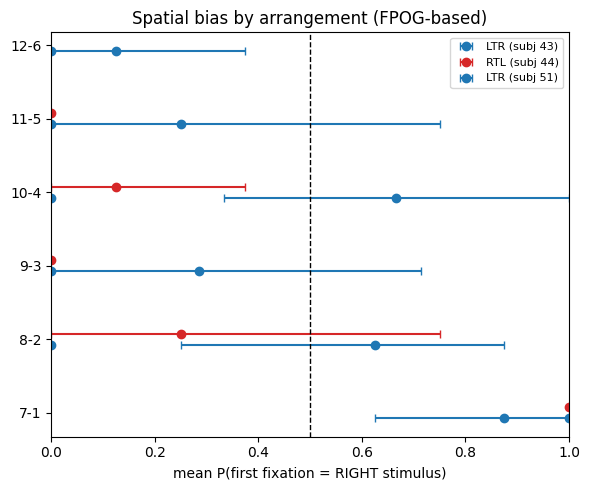

In [13]:
rows = []
for (subj, group, arr), g in df_valid_fpog.groupby(["subject_nr", "group", "arrangement"]):
    is_right = (g["fpog_first_fix_direction"] == "right").astype(float).values
    point, lo, hi = bootstrap_ci(is_right, np.mean)
    rows.append(dict(subject_nr=subj, group=group, arrangement=arr,
                      n_trials=len(g), mean_p_right=point, ci_lo=lo, ci_hi=hi))
choice_df_fpog = pd.DataFrame(rows)
choice_df_fpog["arrangement"] = pd.Categorical(choice_df_fpog["arrangement"], ARRANGEMENT_ORDER, ordered=True)
choice_df_fpog = choice_df_fpog.sort_values(["arrangement", "subject_nr"]).reset_index(drop=True)
choice_df_fpog.to_csv(os.path.join(OUT_DIR, "choice_proportion_by_arrangement_fpog.csv"), index=False)

print("\n=== Mean choice proportion by arrangement (FPOG-recomputed) ===")
print(choice_df_fpog.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 5))
y_pos = {a: i for i, a in enumerate(ARRANGEMENT_ORDER)}
groups_sorted = sorted(choice_df_fpog["group"].unique())
offsets = {g: (i - (len(groups_sorted) - 1) / 2) * 0.15 for i, g in enumerate(groups_sorted)}
for _, row in choice_df_fpog.iterrows():
    y = y_pos[row["arrangement"]] + offsets[row["group"]]
    ax.errorbar(row["mean_p_right"], y,
                xerr=[[row["mean_p_right"] - row["ci_lo"]], [row["ci_hi"] - row["mean_p_right"]]],
                fmt="o", color=colors.get(row["group"], "gray"),
                label=f"{row['group']} (subj {row['subject_nr']})", capsize=3)
ax.axvline(0.5, linestyle="--", color="black", linewidth=1)
ax.set_yticks(range(len(ARRANGEMENT_ORDER)))
ax.set_yticklabels([f"{a[0]}-{a[1]}" for a in ARRANGEMENT_ORDER])
ax.set_xlabel("mean P(first fixation = RIGHT stimulus)")
ax.set_xlim(0, 1)
ax.set_title("Spatial bias by arrangement (FPOG-based)")
handles, labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys(), fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig2_left_choice_proportion_fpog.png"), dpi=150)
plt.show()


=== 20%-winsorized mean RT by clock location (FPOG-based) ===
subject_nr group clock  n_trials  winsor_mean_rt_s    ci_lo    ci_hi
        43   LTR     1         3          0.426393 0.401310 0.455870
        44   RTL     1         2          1.326490 1.212520 1.440460
        51   LTR     1         7          0.260407 0.220106 0.365580
        44   RTL     2         1          0.515720      NaN      NaN
        51   LTR     2         5          0.271726 0.216920 0.389646
        51   LTR     3         2          0.622860 0.207520 1.038200
        44   RTL     4         1          0.401920      NaN      NaN
        51   LTR     4         4          0.267945 0.221070 0.321503
        51   LTR     5         1          0.361570      NaN      NaN
        51   LTR     6         1          0.267950      NaN      NaN
        51   LTR     7         1          0.254520      NaN      NaN
        43   LTR     8         2          0.787050 0.555970 1.018130
        44   RTL     8         3        

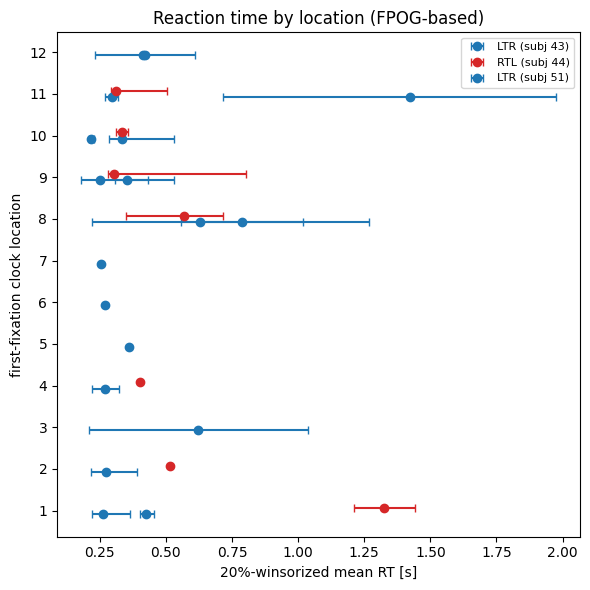

In [14]:
df_rt = df_valid_fpog.copy()
df_rt["clock"] = df_rt.apply(lambda r: clock_for_side(r["arrangement"], r["fpog_first_fix_direction"]), axis=1)

rows = []
for (subj, group, clock), g in df_rt.groupby(["subject_nr", "group", "clock"]):
    rt = g["fpog_first_fix_rt_ms"].values / 1000.0
    point, lo, hi = bootstrap_ci(rt, winsorized_mean)
    rows.append(dict(subject_nr=subj, group=group, clock=clock,
                      n_trials=len(g), winsor_mean_rt_s=point, ci_lo=lo, ci_hi=hi))
rt_df_fpog = pd.DataFrame(rows)
rt_df_fpog["clock"] = pd.Categorical(rt_df_fpog["clock"], CLOCK_ORDER, ordered=True)
rt_df_fpog = rt_df_fpog.sort_values(["clock", "subject_nr"]).reset_index(drop=True)
rt_df_fpog.to_csv(os.path.join(OUT_DIR, "reaction_time_by_location_fpog.csv"), index=False)

print("\n=== 20%-winsorized mean RT by clock location (FPOG-based) ===")
print(rt_df_fpog.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 6))
y_pos = {c: i for i, c in enumerate(CLOCK_ORDER)}
for _, row in rt_df_fpog.iterrows():
    y = y_pos[row["clock"]] + offsets.get(row["group"], 0)
    lo = row["winsor_mean_rt_s"] - row["ci_lo"] if not np.isnan(row["ci_lo"]) else 0
    hi = row["ci_hi"] - row["winsor_mean_rt_s"] if not np.isnan(row["ci_hi"]) else 0
    ax.errorbar(row["winsor_mean_rt_s"], y, xerr=[[lo], [hi]], fmt="o",
                color=colors.get(row["group"], "gray"),
                label=f"{row['group']} (subj {row['subject_nr']})", capsize=3)
ax.set_yticks(range(len(CLOCK_ORDER)))
ax.set_yticklabels([str(c) for c in CLOCK_ORDER])
ax.set_ylabel("first-fixation clock location")
ax.set_xlabel("20%-winsorized mean RT [s]")
ax.set_title("Reaction time by location (FPOG-based)")
handles, labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys(), fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig2_right_reaction_times_fpog.png"), dpi=150)
plt.show()

Bradley-Terry-style logistic regression of first-fixation side (FPOG-based).

In [15]:
d = df_valid_fpog.copy()
d["y_right"] = (d["fpog_first_fix_direction"] == "right").astype(int)
d["arrangement_str"] = d["arrangement"].astype(str)
mod = smf.logit("y_right ~ C(arrangement_str) + C(group)", data=d)
# Perfect separation may raise PerfectSeparationError, raise LinAlgError, or
# "succeed" with inf/diverged coefficients and only a warning -- catch all three.
note = ""
try:
    model = mod.fit(disp=False)
    if bt_fit_is_suspect(model):
        raise PerfectSeparationError("fit diverged (non-finite or huge coefficients)")
except (np.linalg.LinAlgError, PerfectSeparationError):
    model = mod.fit_regularized(alpha=0.5, disp=False)
    note = ("[NOTE: unregularized fit hit perfect separation / divergence -- "
            "some arrangement x group cells are all-left or all-right with "
            "this small n. Refit with an L1 penalty below; treat coefficients "
            "as descriptive only, not as p<.05-testable effects, until you "
            "add more subjects.]\n")

print("\n=== Bradley-Terry-style logistic regression: P(right) ~ arrangement + group (FPOG-based) ===")
if note:
    print(note)
print(model.summary() if hasattr(model, "summary") else model.params)
print("\nCAUTION: RTL still has only 1 subject, so `group` is confounded with "
      "`subject_nr` for that group -- treat as descriptive/pilot output only.")

with open(os.path.join(OUT_DIR, "bradley_terry_model_summary_fpog.txt"), "w") as f:
    f.write(note)
    f.write(str(model.summary() if hasattr(model, "summary") else model.params))


=== Bradley-Terry-style logistic regression: P(right) ~ arrangement + group (FPOG-based) ===
                           Logit Regression Results                           
Dep. Variable:                y_right   No. Observations:                  101
Model:                          Logit   Df Residuals:                       94
Method:                           MLE   Df Model:                            6
Date:                Wed, 15 Jul 2026   Pseudo R-squ.:                  0.3623
Time:                        02:18:02   Log-Likelihood:                -37.396
converged:                       True   LL-Null:                       -58.639
Covariance Type:            nonrobust   LLR p-value:                 1.475e-07
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -0.8833      0.545     -1.621      0.105     

Extra: LTR vs RTL reading-onset congruence (FPOG-based). Uses the same
`fix_matches_reading_onset` column computed in Section 4 from
`first_fix_direction` — recomputed here against `fpog_first_fix_direction`.

In [16]:
df_valid_fpog["fix_matches_reading_onset"] = (
    df_valid_fpog["fpog_first_fix_direction"] == df_valid_fpog["reading_start_side"]
).where(df_valid_fpog["fpog_first_fix_direction"] != "none")


=== P(first fixation matches reading-onset side), by group (FPOG-based) ===
(reading-onset side = left for LTR readers, right for RTL readers)
subject_nr group  n_trials  p_reading_congruent    ci_lo    ci_hi
        43   LTR        30             0.900000 0.800000 1.000000
        44   RTL        30             0.133333 0.033333 0.266667
        51   LTR        41             0.512195 0.365854 0.658537

2x2 table (group x matches-reading-onset):
fix_matches_reading_onset  False  True 
group                                  
LTR                           23     48
RTL                           26      4

Fisher's exact test: odds ratio = 0.074, p = 0.0000

CAUTION: with 1 subject per group this compares two individuals, not two populations.


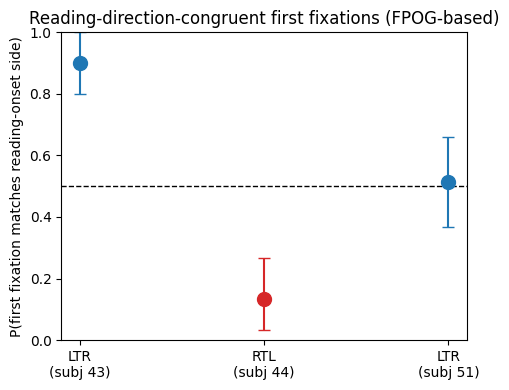

In [17]:
rows = []
for (subj, group), g in df_valid_fpog.groupby(["subject_nr", "group"]):
    match = g["fix_matches_reading_onset"].dropna().astype(float).values
    point, lo, hi = bootstrap_ci(match, np.mean)
    rows.append(dict(subject_nr=subj, group=group, n_trials=len(match),
                      p_reading_congruent=point, ci_lo=lo, ci_hi=hi))
congruence_df_fpog = pd.DataFrame(rows)
congruence_df_fpog.to_csv(os.path.join(OUT_DIR, "reading_congruence_by_group_fpog.csv"), index=False)

table = (df_valid_fpog.dropna(subset=["fix_matches_reading_onset"])
         .groupby(["group", "fix_matches_reading_onset"]).size().unstack(fill_value=0))
odds_ratio, fisher_p = (np.nan, np.nan)
if table.shape == (2, 2):
    odds_ratio, fisher_p = stats.fisher_exact(table.values)

print("\n=== P(first fixation matches reading-onset side), by group (FPOG-based) ===")
print("(reading-onset side = left for LTR readers, right for RTL readers)")
print(congruence_df_fpog.to_string(index=False))
print("\n2x2 table (group x matches-reading-onset):")
print(table)
if not np.isnan(fisher_p):
    print(f"\nFisher's exact test: odds ratio = {odds_ratio:.3f}, p = {fisher_p:.4f}")
print("\nCAUTION: with 1 subject per group this compares two individuals, not two populations.")

fig, ax = plt.subplots(figsize=(5, 4))
for i, row in enumerate(congruence_df_fpog.itertuples()):
    lo = row.p_reading_congruent - row.ci_lo if not np.isnan(row.ci_lo) else 0
    hi = row.ci_hi - row.p_reading_congruent if not np.isnan(row.ci_hi) else 0
    ax.errorbar(i, row.p_reading_congruent, yerr=[[lo], [hi]], fmt="o",
                markersize=10, color=colors.get(row.group, "gray"), capsize=4)
ax.axhline(0.5, linestyle="--", color="black", linewidth=1)
ax.set_xticks(range(len(congruence_df_fpog)))
ax.set_xticklabels([f"{r.group}\n(subj {r.subject_nr})" for r in congruence_df_fpog.itertuples()])
ax.set_ylabel("P(first fixation matches reading-onset side)")
ax.set_ylim(0, 1)
ax.set_title("Reading-direction-congruent first fixations (FPOG-based)")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "extra_reading_congruence_fpog.png"), dpi=150)
plt.show()

## 9. Orientation-decomposed bias: left/right vs up/down

Section 3 noted that `img_left`/`img_right` is a 7–12-o'clock vs 1–6-o'clock
split, not strictly a screen-left/right split — arrangement `(12, 6)` has no
horizontal component at all. Rather than pool all six arrangements into one
`mean_p_right` number, `fixated_clock` (the actual clock hour of the first
fixation, already computed per trial) is decomposed into two independent,
well-defined contrasts:

- **left/right**: only defined when the fixated hour is not `6` or `12`
  (those sit on the vertical meridian, `x=0`) — i.e. arrangement `(12, 6)`
  contributes nothing here, the other five do.
- **up/down**: only defined when the fixated hour is not `3` or `9` (those
  sit on the horizontal meridian, `y=0`) — arrangement `(9, 3)` contributes
  nothing here, the other five do.

Each trial can therefore contribute to at most one of the two contrasts
(never both, except the four diagonal arrangements which contribute to
both), and `(12,6)`/`(9,3)` each drop out of exactly one.

=== Pooled left/right bias (excludes arrangement (12,6)), FPOG-based ===
subject_nr group  n_trials  mean_p_right    ci_lo    ci_hi
        43   LTR        29      0.103448 0.000000 0.241379
        44   RTL        30      0.133333 0.033333 0.266667
        51   LTR        33      0.575758 0.393939 0.727273

=== Pooled up/down bias (excludes arrangement (9,3)), FPOG-based ===
subject_nr group  n_trials  mean_p_up    ci_lo    ci_hi
        43   LTR        22   0.909091 0.772727 1.000000
        44   RTL        22   0.818182 0.636364 0.954545
        51   LTR        34   0.705882 0.558824 0.852941


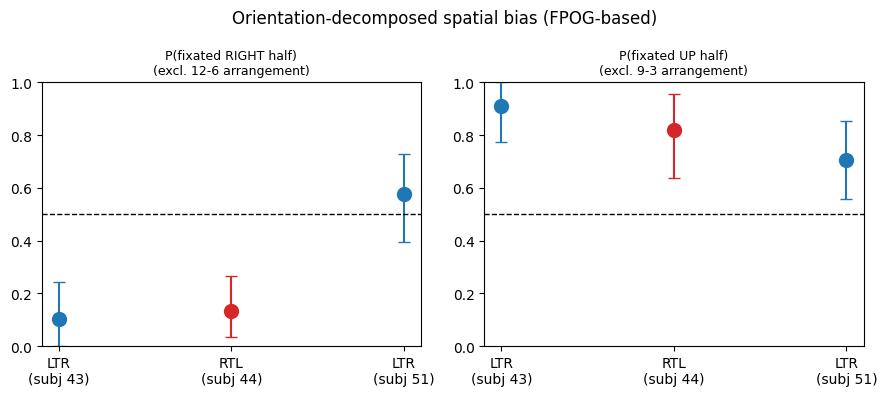

In [18]:
def orientation_bias_table(df, axis_col, positive_label):
    rows = []
    for (subj, group), g in df.dropna(subset=[axis_col]).groupby(["subject_nr", "group"]):
        is_positive = (g[axis_col] == positive_label).astype(float).values
        point, lo, hi = bootstrap_ci(is_positive, np.mean)
        rows.append(dict(subject_nr=subj, group=group, n_trials=len(g),
                          **{f"mean_p_{positive_label}": point, "ci_lo": lo, "ci_hi": hi}))
    return pd.DataFrame(rows)


lr_df = orientation_bias_table(df_valid_fpog, "physical_side", "right")
ud_df = orientation_bias_table(df_valid_fpog, "physical_vert", "up")

lr_df.to_csv(os.path.join(OUT_DIR, "leftright_bias_fpog.csv"), index=False)
ud_df.to_csv(os.path.join(OUT_DIR, "updown_bias_fpog.csv"), index=False)

print("=== Pooled left/right bias (excludes arrangement (12,6)), FPOG-based ===")
print(lr_df.to_string(index=False))
print("\n=== Pooled up/down bias (excludes arrangement (9,3)), FPOG-based ===")
print(ud_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, table, key, title in [
    (axes[0], lr_df, "mean_p_right", "P(fixated RIGHT half)\n(excl. 12-6 arrangement)"),
    (axes[1], ud_df, "mean_p_up", "P(fixated UP half)\n(excl. 9-3 arrangement)"),
]:
    for i, row in enumerate(table.itertuples()):
        val = getattr(row, key)
        lo = val - row.ci_lo if not np.isnan(row.ci_lo) else 0
        hi = row.ci_hi - val if not np.isnan(row.ci_hi) else 0
        ax.errorbar(i, val, yerr=[[lo], [hi]], fmt="o", markersize=10,
                     color=colors.get(row.group, "gray"), capsize=4)
    ax.axhline(0.5, linestyle="--", color="black", linewidth=1)
    ax.set_xticks(range(len(table)))
    ax.set_xticklabels([f"{r.group}\n(subj {r.subject_nr})" for r in table.itertuples()])
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=9)
fig.suptitle("Orientation-decomposed spatial bias (FPOG-based)")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "orientation_bias_fpog.png"), dpi=150)
plt.show()

### 9b. LTR vs RTL, pooled by group

The per-subject view above answers "does each subject show a bias"; this
pools *within* each reading-direction group so LTR and RTL sit side by side
and every direction (left, right, up, down) is visible on the same 0–1 scale
in one plot.

Two things to read correctly:

- **Trials from the same subject are not independent**, so the group CI uses
  the hierarchical bootstrap from Section 5 (resample subjects, then trials
  within subjects) and the bar height is the unweighted mean of subject
  means. The small dots overlaid on each bar are the individual subject
  means — with few subjects the honest group uncertainty is wide, and the
  dots show whether subjects even agree. This scales unchanged to 10+
  subjects. (For RTL with a single subject the CI degenerates to that
  subject's trial bootstrap.)
- **The four bars are not four independent probabilities**: within each
  group, `P(down) = 1 − P(up)` and `P(left) = 1 − P(right)` by construction
  (each axis is a binary contrast). Showing all four is purely for
  readability. The clock-face plot in 9c shows the full 12-direction
  breakdown these bars summarize.

=== P(first fixation in each direction), by group (FPOG-based) ===
(bar = mean of subject means; CI = hierarchical bootstrap)
group direction  n_subjects  n_trials        p    ci_lo    ci_hi
  LTR     right           2        62 0.339603 0.051724 0.651515
  LTR      left           2        62 0.660397 0.348485 0.948276
  RTL     right           1        30 0.133333 0.033333 0.266667
  RTL      left           1        30 0.866667 0.733333 0.966667
  LTR        up           2        56 0.807487 0.632353 0.954545
  LTR      down           2        56 0.192513 0.045455 0.367647
  RTL        up           1        22 0.818182 0.636364 0.954545
  RTL      down           1        22 0.181818 0.045455 0.363636


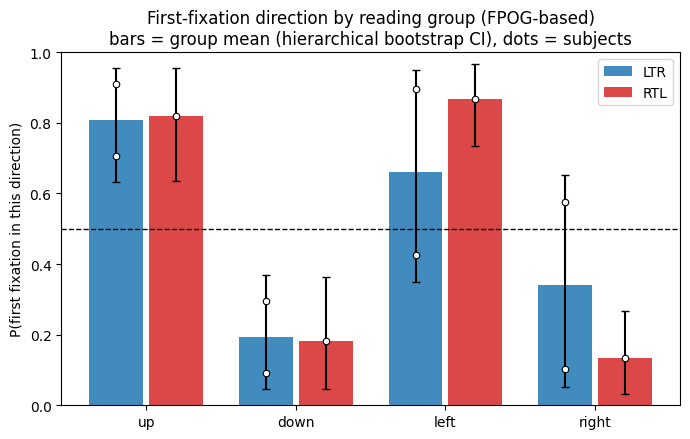

In [19]:
def pooled_orientation_table(df, axis_col, positive_label, negative_label):
    rows, subj_rows = [], []
    for group, g in df.dropna(subset=[axis_col]).groupby("group"):
        per_subj = [(subj, (sg[axis_col] == positive_label).astype(float).values)
                    for subj, sg in g.groupby("subject_nr")]
        arrays = [a for _, a in per_subj]
        p_pos, lo_pos, hi_pos = hierarchical_bootstrap_ci(arrays)
        rows.append(dict(group=group, direction=positive_label, n_subjects=len(arrays),
                          n_trials=len(g), p=p_pos, ci_lo=lo_pos, ci_hi=hi_pos))
        rows.append(dict(group=group, direction=negative_label, n_subjects=len(arrays),
                          n_trials=len(g), p=1 - p_pos, ci_lo=1 - hi_pos, ci_hi=1 - lo_pos))
        for subj, a in per_subj:
            m = a.mean()
            subj_rows.append(dict(group=group, subject_nr=subj,
                                   direction=positive_label, p=m))
            subj_rows.append(dict(group=group, subject_nr=subj,
                                   direction=negative_label, p=1 - m))
    return pd.DataFrame(rows), pd.DataFrame(subj_rows)


group_lr, subj_lr = pooled_orientation_table(df_valid_fpog, "physical_side", "right", "left")
group_ud, subj_ud = pooled_orientation_table(df_valid_fpog, "physical_vert", "up", "down")
group_dir = pd.concat([group_lr, group_ud], ignore_index=True)
subj_dir = pd.concat([subj_lr, subj_ud], ignore_index=True)
group_dir.to_csv(os.path.join(OUT_DIR, "group_orientation_bias_fpog.csv"), index=False)

print("=== P(first fixation in each direction), by group (FPOG-based) ===")
print("(bar = mean of subject means; CI = hierarchical bootstrap)")
print(group_dir.to_string(index=False))

direction_order = ["up", "down", "left", "right"]
groups_present = sorted(group_dir["group"].unique())
fig, ax = plt.subplots(figsize=(7, 4.5))
n_groups = len(groups_present)
width = 0.8 / n_groups
x = np.arange(len(direction_order))
for gi, group in enumerate(groups_present):
    sub = group_dir[group_dir["group"] == group].set_index("direction").reindex(direction_order)
    xpos = x + (gi - (n_groups - 1) / 2) * width
    lo = (sub["p"] - sub["ci_lo"]).values
    hi = (sub["ci_hi"] - sub["p"]).values
    ax.bar(xpos, sub["p"], width=width * 0.9, color=colors.get(group, "gray"),
           label=group, yerr=[lo, hi], capsize=3, alpha=0.85)
    ssub = subj_dir[subj_dir["group"] == group]
    for di, direction in enumerate(direction_order):
        pts = ssub.loc[ssub["direction"] == direction, "p"]
        ax.scatter(np.full(len(pts), xpos[di]), pts, s=22, zorder=3,
                   facecolor="white", edgecolor="black", linewidth=0.8)
ax.axhline(0.5, linestyle="--", color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(direction_order)
ax.set_ylim(0, 1)
ax.set_ylabel("P(first fixation in this direction)")
ax.set_title("First-fixation direction by reading group (FPOG-based)\n"
             "bars = group mean (hierarchical bootstrap CI), dots = subjects")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "group_orientation_bias_fpog.png"), dpi=150)
plt.show()

### 9c. Clock-face view: P(first fixation) per clock hour

The stimuli are arranged on a circle, so the most direct picture of the bias
is the circle itself. For each clock hour *h*: among the trials where *h*
was one of the two presented positions, the proportion whose first fixation
landed on *h*. Chance is 0.5 everywhere (dashed circle). Each hour appears
in exactly one arrangement, so per subject each hour has at most 8 trials —
thin lines are individual subjects (noisy by construction), thick lines are
the group mean-of-subject-means. Opposite hours are mirror images
(`P(h) = 1 − P(h+6)` on the same trials), same caveat as the bars in 9b.

=== P(first fixation on hour h | h presented), by group ===
group    LTR    RTL
hour               
1      0.938  1.000
2      0.312  0.250
3      0.143  0.000
4      0.333  0.125
5      0.125  0.000
6      0.062    NaN
7      0.062  0.000
8      0.688  0.750
9      0.857  1.000
10     0.667  0.875
11     0.875  1.000
12     0.938    NaN


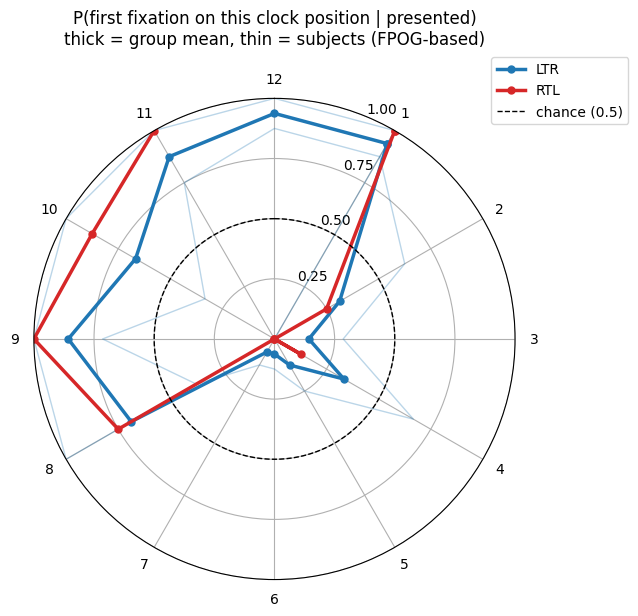

In [20]:
rows = []
for _, r in df_valid_fpog.dropna(subset=["fixated_clock"]).iterrows():
    for h in r["arrangement"]:
        rows.append(dict(group=r["group"], subject_nr=r["subject_nr"], hour=int(h),
                          fixated=float(r["fixated_clock"] == h)))
clock_long = pd.DataFrame(rows)

subj_clock = (clock_long.groupby(["group", "subject_nr", "hour"])["fixated"]
              .agg(["mean", "count"]).reset_index())
group_clock = (subj_clock.groupby(["group", "hour"])["mean"]
               .mean().reset_index(name="p"))  # mean of subject means
group_clock.to_csv(os.path.join(OUT_DIR, "clock_face_bias_fpog.csv"), index=False)

print("=== P(first fixation on hour h | h presented), by group ===")
print(group_clock.pivot(index="hour", columns="group", values="p").round(3).to_string())


fig, ax = plt.subplots(figsize=(6.5, 6.5), subplot_kw=dict(projection="polar"))
ax.set_theta_zero_location("N")   # 12 o'clock at top
ax.set_theta_direction(-1)        # hours increase clockwise
hours = CLOCK_ORDER
theta = [h * np.pi / 6 for h in hours]
theta_closed = theta + [theta[0]]

# NaN (an hour with no surviving trials, e.g. all excluded) leaves a gap in
# that group's line rather than being silently interpolated
for (group, subj), g in subj_clock.groupby(["group", "subject_nr"]):
    vals = g.set_index("hour")["mean"].reindex(hours).values
    ax.plot(theta_closed, np.append(vals, vals[0]), color=colors.get(group, "gray"),
            alpha=0.3, linewidth=1)
for group, g in group_clock.groupby("group"):
    vals = g.set_index("hour")["p"].reindex(hours).values
    ax.plot(theta_closed, np.append(vals, vals[0]), color=colors.get(group, "gray"),
            linewidth=2.5, marker="o", markersize=5, label=group)

circle_theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(circle_theta, np.full_like(circle_theta, 0.5), "--", color="black",
        linewidth=1, label="chance (0.5)")

ax.set_xticks(theta)
ax.set_xticklabels([str(h) for h in hours])
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_title("P(first fixation on this clock position | presented)\n"
             "thick = group mean, thin = subjects (FPOG-based)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "clock_face_bias_fpog.png"), dpi=150)
plt.show()

## 10. Summary / open caveats

- The clock-hour mislabeling (Section 3) and the `first_fix_side` logging
  bug (Section 7) were both confirmed against real data, not just inferred
  from reading the code — and the experiment script's own "FIX (V8)" comment
  (HiDPI `win.size` coordinate mismatch) matches the observed failure mode
  for subjects 43/44.
- The FPOG recomputation uses the **same AOI as the experiment's online
  detection** (square, half-width 150 px around each stimulus center, from
  `V7_AttentionalSpatialBias_.osexp`), applied to tracker-classified
  fixations instead of single raw samples, with two candidate filters: the
  fixation must start at/after stimulus onset, and first fixations faster
  than 80 ms are excluded as anticipatory.
- Group-pooled estimates (9b/9c) use a hierarchical bootstrap (subjects,
  then trials) with mean-of-subject-means point estimates, so they remain
  valid as-is when the sample grows to 10+ subjects.
- RTL still has only 1 subject (44), so `group` remains confounded with
  `subject_nr` for that group — none of the LTR-vs-RTL numbers above should
  be read as evidence for or against a reading-direction effect until more
  RTL subjects are added.
- All tables/plots are also saved under `results/`, with `_csv`/`_fpog`
  suffixes distinguishing the two first-fixation sources.
- Cells are written to be safe to re-run out of order where cheap (the FPOG
  merge drops stale `fpog_*` columns first), but the intended workflow is
  still **Run All, top to bottom**.